# Pairs-trading simulation on HD (Home Depot) & SHW (Sherman-Williams)

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# 1. Prices -> log prices
px = yf.download(["HD", "SHW"], start="2015-01-01", end="2025-01-01",
                 auto_adjust=True)["Close"]
logp = np.log(px).dropna()

# 2. One function: Engle–Granger test + the hedge regression it runs internally
def eg_test(x, y):
    stat, pval, crit = coint(x, y)                  # regression 1 + ADF on residuals
    ols = sm.OLS(x, sm.add_constant(y)).fit()       # same regression, to see beta and mu
    return {"EG stat": stat, "p-value": pval, "5% crit": crit[1],
            "mu_hat": ols.params.iloc[0], "beta_hat": ols.params.iloc[1],
            "R2": ols.rsquared}

# 3. Both directions
results = pd.DataFrame({
    "HD on SHW": eg_test(logp["HD"],  logp["SHW"]),
    "SHW on HD": eg_test(logp["SHW"], logp["HD"]),
}).T
results

[*********************100%***********************]  2 of 2 completed


,EG stat,p-value,5% crit,mu_hat,beta_hat,R2
HD on SHW,-4.961325,0.000194,-3.338561,0.426180,0.941065,0.978729
SHW on HD,-4.883549,0.000268,-3.338561,-0.334846,1.040023,0.978729


Both pairs pass the test across the full 2015-2025 period. Now, we'll make a function called backtest_window, which will train on a window of years and then trade on the next year (walk-forward). The purpose is to remove look-ahead bias.
If, for a given window, the Engle-Granger test returns a p-value $\geq$ 0.05, we will **not** trade in the following year.

In [2]:
def backtest_window(logp, x, y, form_start, trade_start, trade_end,
                    entry=2.0, z_exit=0.0, stop=None,
                    capital=100_000, borrow_fee=0.003, tc_bps=5.0, p_max=0.05):
    # ---- 1. Split into formation and trading windows (half-open) ----
    idx = logp.index
    form  = logp.loc[(idx >= form_start)  & (idx < trade_start)]
    trade = logp.loc[(idx >= trade_start) & (idx < trade_end)]

    # ---- 2. Formation: test, then freeze beta, mu, sigma ----
    _, pval, _ = coint(form[x], form[y])
    ols   = sm.OLS(form[x], sm.add_constant(form[y])).fit()
    mu, beta = ols.params.iloc[0], ols.params.iloc[1]
    sigma = ols.resid.std(ddof=1)
    info = dict(form_start=form_start, trade_start=trade_start, trade_end=trade_end,
                p_value=pval, beta=beta, mu=mu, sigma=sigma, traded=bool(pval < p_max))

    # ---- 3. Trading window: z-score with the FROZEN parameters ----
    z  = (trade[x] - beta * trade[y] - mu) / sigma
    px = np.exp(trade)                       # back to dollar prices for P&L
    dates = trade.index

    n = {x: 0.0, y: 0.0}                     # shares held (negative = short)
    state, target, wait, n_trades = 0, 0, False, 0
    rows = []
    for i, t in enumerate(dates):
        P = px.loc[t]
        gross = borrow = tc = 0.0

        # (a) P&L from yesterday's holdings
        if i > 0:
            prev = dates[i - 1]
            dP = P - px.loc[prev]
            gross = n[x] * dP[x] + n[y] * dP[y]
            short_val = sum(-n[c] * px.loc[prev, c] for c in (x, y) if n[c] < 0)
            borrow = borrow_fee / 360 * short_val * (t - prev).days

        # (b) Execute yesterday's decision at today's close; force-close on last day
        if i == len(dates) - 1:
            target = 0
        if target != state:
            D = capital / (1 + beta)                       # gross exposure = capital
            new = {x:  target * D / P[x],
                   y: -target * beta * D / P[y]}
            tc = tc_bps / 1e4 * sum(abs(new[c] - n[c]) * P[c] for c in (x, y))
            if state == 0:
                n_trades += 1
            n, state = new, target

        # (c) Decide tomorrow's position from today's z
        zt = z.loc[t]
        if wait and abs(zt) < entry:          # after a stop, wait for z to come back inside ±entry
            wait = False
        if state == 0 and info["traded"] and not wait:
            if zt > entry:    target = -1     # spread rich: short x, long y
            elif zt < -entry: target = +1     # spread cheap: long x, short y
        elif state == +1:
            if zt >= -z_exit:                        target = 0
            elif stop is not None and zt < -stop:    target, wait = 0, True
        elif state == -1:
            if zt <= z_exit:                         target = 0
            elif stop is not None and zt > stop:     target, wait = 0, True

        rows.append(dict(date=t, z=zt, position=state, gross=gross,
                         borrow=borrow, tc=tc, net=gross - borrow - tc))

    daily = pd.DataFrame(rows).set_index("date")
    info.update(n_trades=n_trades, gross_pnl=daily["gross"].sum(),
                borrow=daily["borrow"].sum(), tc=daily["tc"].sum(),
                net_pnl=daily["net"].sum())
    return info, daily

In [8]:
info, daily = backtest_window(logp, "HD", "SHW", "2015-01-01", "2022-01-01", "2023-01-01", stop=4)
info

{'form_start': '2015-01-01',
 'trade_start': '2022-01-01',
 'trade_end': '2023-01-01',
 'p_value': 0.0026456990603072167,
 'beta': np.float64(0.9246286996751233),
 'mu': np.float64(0.4974097957556254),
 'sigma': np.float64(0.06667905863067726),
 'traded': True,
 'n_trades': 2,
 'gross_pnl': np.float64(8847.886366165103),
 'borrow': np.float64(48.519730849138824),
 'tc': np.float64(208.37168122603933),
 'net_pnl': np.float64(8590.994954089925)}

In [10]:
import matplotlib.pyplot as plt

def walk_forward(logp, x, y, form_years, trade_years, **kw):
    """Run backtest_window once per trading year. Returns (summary table, daily frame)."""
    infos, dailies = [], []
    for yr in trade_years:
        info, daily = backtest_window(logp, x, y,
                                      form_start=f"{yr - form_years}-01-01",
                                      trade_start=f"{yr}-01-01",
                                      trade_end=f"{yr + 1}-01-01", **kw)
        info["year"] = yr
        infos.append(info)
        dailies.append(daily.assign(year=yr))
    summary = pd.DataFrame(infos).set_index("year")
    summary["return_%"] = 100 * summary["net_pnl"] / kw.get("capital", 100_000)
    return summary, pd.concat(dailies)

trade_years = range(2018, 2025)
runs = {L: walk_forward(logp, "HD", "SHW", form_years=L, trade_years=trade_years, stop=4)
        for L in (1, 2, 3)}

for L, (summary, _) in runs.items():
    print(f"\n=== formation = {L} year(s) ===")
    print(summary[["p_value", "traded", "beta", "sigma", "n_trades",
                   "gross_pnl", "borrow", "tc", "net_pnl", "return_%"]].round(3))
    print("total net P&L:", round(summary["net_pnl"].sum(), 2))


=== formation = 1 year(s) ===
      p_value  traded   beta  sigma  n_trades  gross_pnl  borrow   tc  \
year                                                                    
2018    0.496   False  0.763  0.030         0        0.0     0.0  0.0   
2019    0.426   False  0.739  0.042         0        0.0     0.0  0.0   
2020    0.331   False  0.678  0.038         0        0.0     0.0  0.0   
2021    0.303   False  0.875  0.045         0        0.0     0.0  0.0   
2022    0.246   False  1.021  0.038         0        0.0     0.0  0.0   
2023    0.334   False  0.656  0.053         0        0.0     0.0  0.0   
2024    0.305   False  0.538  0.033         0        0.0     0.0  0.0   

      net_pnl  return_%  
year                     
2018      0.0       0.0  
2019      0.0       0.0  
2020      0.0       0.0  
2021      0.0       0.0  
2022      0.0       0.0  
2023      0.0       0.0  
2024      0.0       0.0  
total net P&L: 0.0

=== formation = 2 year(s) ===
      p_value  traded   bet

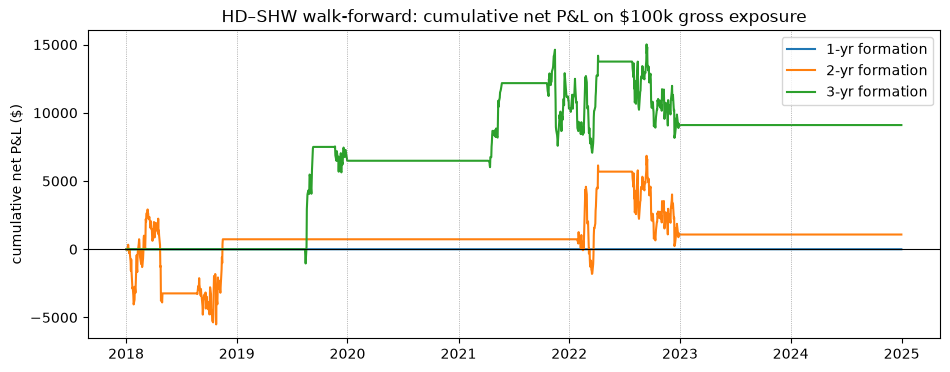

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
for L, (_, daily) in runs.items():
    ax.plot(daily.index, daily["net"].cumsum(), label=f"{L}-yr formation")
for yr in trade_years:
    ax.axvline(pd.Timestamp(f"{yr}-01-01"), color="grey", lw=0.5, ls=":")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("cumulative net P&L ($)")
ax.set_title("HD–SHW walk-forward: cumulative net P&L on $100k gross exposure")
ax.legend()
plt.show()

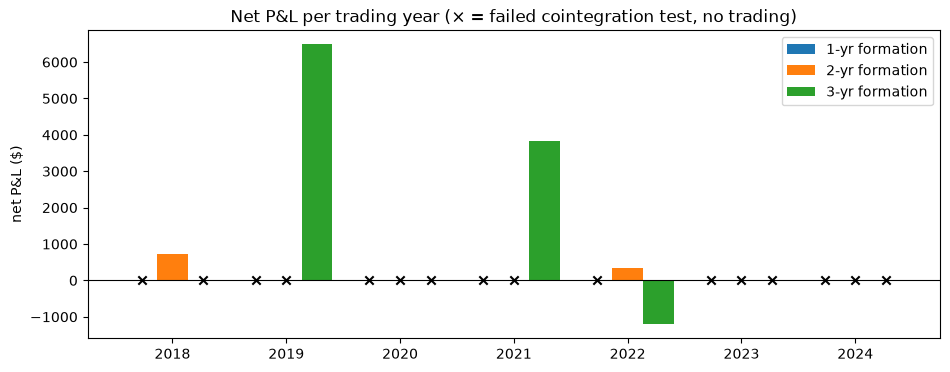

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
w = 0.27
for k, (L, (summary, _)) in enumerate(runs.items()):
    xs = np.arange(len(summary)) + (k - 1) * w
    ax.bar(xs, summary["net_pnl"], width=w, label=f"{L}-yr formation")
    off = ~summary["traded"]
    ax.scatter(xs[off.values], np.zeros(off.sum()), marker="x", color="black", zorder=3)
ax.set_xticks(np.arange(len(trade_years)), list(trade_years))
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("net P&L ($)")
ax.set_title("Net P&L per trading year (× = failed cointegration test, no trading)")
ax.legend()
plt.show()

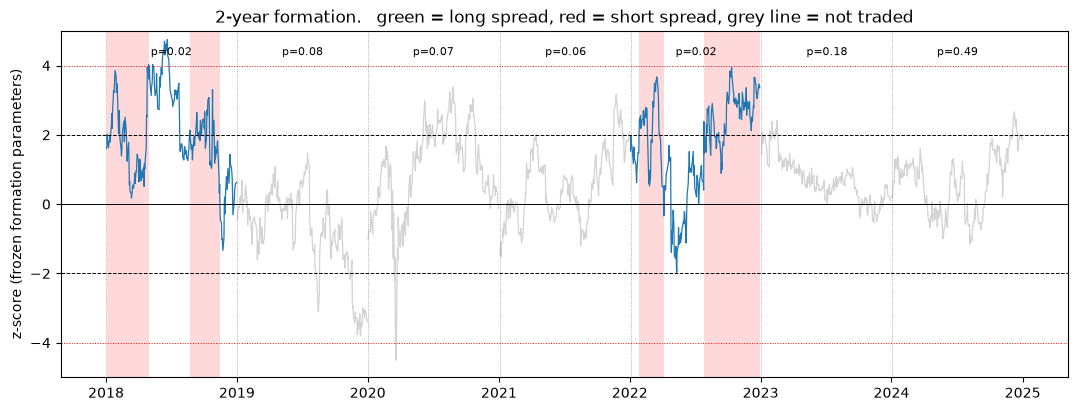

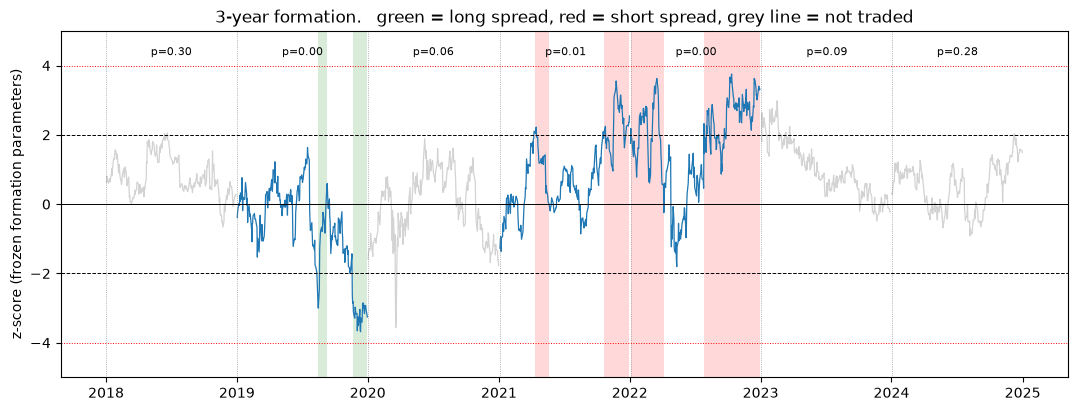

In [14]:
def plot_z(daily, summary, entry=2.0, stop=4, title=""):
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for yr, d in daily.groupby("year"):
        traded = summary.loc[yr, "traded"]
        ax.plot(d.index, d["z"], color="C0" if traded else "lightgrey", lw=0.9)
        ax.fill_between(d.index, -5, 5, where=d["position"] == +1, color="green", alpha=0.15, lw=0)
        ax.fill_between(d.index, -5, 5, where=d["position"] == -1, color="red",   alpha=0.15, lw=0)
        ax.text(d.index[len(d) // 2], 4.3, f"p={summary.loc[yr, 'p_value']:.2f}",
                ha="center", fontsize=8)
        ax.axvline(d.index[0], color="grey", lw=0.5, ls=":")
    for lvl, ls in [(entry, "--"), (-entry, "--"), (0, "-")]:
        ax.axhline(lvl, color="black", lw=0.7, ls=ls)
    if stop:
        for lvl in (stop, -stop):
            ax.axhline(lvl, color="red", lw=0.7, ls=":")
    ax.set_ylim(-5, 5)
    ax.set_ylabel("z-score (frozen formation parameters)")
    ax.set_title(title + "   green = long spread, red = short spread, grey line = not traded")
    plt.show()

summary2, daily2 = runs[2]
plot_z(daily2, summary2, title="2-year formation.")

summary3, daily3 = runs[3]
plot_z(daily3, summary3, title="3-year formation.")

In [16]:
%pip install jinja2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
# 1. Collect net P&L and the traded flag from each run
pnl    = pd.DataFrame({f"{L}-yr formation": s["net_pnl"] for L, (s, _) in runs.items()})
traded = pd.DataFrame({f"{L}-yr formation": s["traded"]  for L, (s, _) in runs.items()})
pnl.index.name = "trading year"

# 2. Add a total row (no-trade years contribute 0)
pnl.loc["Total"]    = pnl.sum()
traded.loc["Total"] = True          # always colour the total row by sign

# 3. Colour rule: grey for no trading, otherwise green / red by sign
def colour(col):
    styles = []
    for year, v in col.items():
        if not traded.loc[year, col.name]:
            styles.append("color: #9e9e9e")
        elif v > 0:
            styles.append("color: #1b8a3a; font-weight: 600")
        elif v < 0:
            styles.append("color: #c62828; font-weight: 600")
        else:
            styles.append("")
    return styles

(pnl.style
    .apply(colour, axis=0)
    .format("${:,.0f}")
    .set_caption("HD–SHW net P&L per trading year, $100k gross exposure "
                 "(grey = formation test failed, no trading)")
    .set_table_styles([
        {"selector": "caption", "props": "font-weight: 600; padding-bottom: 6px"},
        {"selector": "tr:last-child td, tr:last-child th",
         "props": "border-top: 2px solid #555; font-weight: 700"},
    ]))

,1-yr formation,2-yr formation,3-yr formation
trading year,,,
2018,$0,$730,$0
2019,$0,$0,"$6,486"
2020,$0,$0,$0
2021,$0,$0,"$3,825"
2022,$0,$349,"$-1,209"
2023,$0,$0,$0
2024,$0,$0,$0
Total,$0,"$1,079","$9,103"
